RQ2: What patterns of positive, neutral, and negative framing are used in German media when reporting on social movements, and how do these patterns vary across different news outlets? (Bild vs. Tagesschau)

Source: tagesschau_zdf_pbs_foxnews_bild_gkg_partitioned_full.csv 

Visualization: Grouped Bar Chart


Total rows: 292,678
Columns: ['DATE', 'SourceCommonName', 'url', 'V2Persons', 'V2Organizations', 'V2Tone']

── Records per outlet ──
Outlet
Other         158958
Bild          100502
Tagesschau     33218

Tagesschau + Bild records: 133,720

── Social movement articles found ──
Outlet
Bild          1533
Tagesschau    1035

── After deduplication ──
Outlet
Bild          1533
Tagesschau    1035

── Mean AvgTone ──
Outlet
Bild         -3.650
Tagesschau   -4.293

── Tone Distribution per Outlet (%) ──
    Outlet ToneLabel  Count  Total       Pct
      Bild  Negative   1253   1533 81.735160
      Bild   Neutral    169   1533 11.024136
      Bild  Positive    111   1533  7.240705
Tagesschau  Negative    929   1035 89.758454
Tagesschau   Neutral     91   1035  8.792271
Tagesschau  Positive     15   1035  1.449275


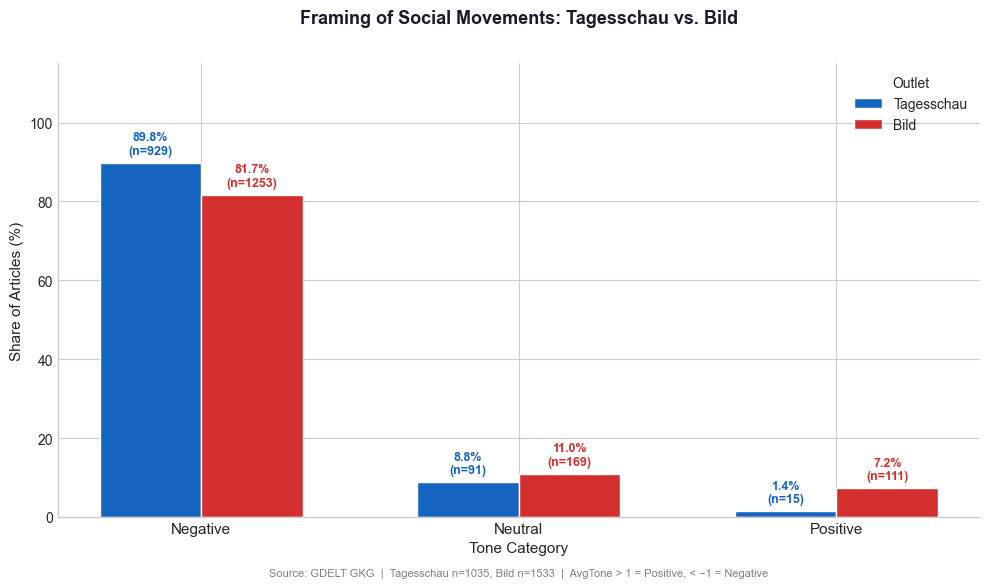

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ─────────────────────────────────────────────────────────────────────
FOLDER   = r"C:\Users\User\Desktop\DataScienceProjectGroup8"
GKG_FILE = "tagesschau_zdf_pbs_foxnews_bild_gkg_partitioned_full.csv"

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  1. LOAD DATA                                                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝

df_raw = pd.read_csv(os.path.join(FOLDER, GKG_FILE),
                     on_bad_lines='skip', low_memory=False)

print(f"Total rows: {len(df_raw):,}")
print(f"Columns: {list(df_raw.columns)}")

# ── Spalten manuell setzen ─────────────────────────────────────────────────────
url_col   = 'url'
tone_col  = 'V2Tone'
theme_col = None        # nicht vorhanden
date_col  = 'DATE'

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  2. OUTLET LABELING                                                    ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def label_outlet(url):
    url = str(url).lower()
    if 'tagesschau.de' in url: return 'Tagesschau'
    elif 'bild.de'     in url: return 'Bild'
    else:                      return 'Other'

df_raw['Outlet'] = df_raw[url_col].apply(label_outlet)

print("\n── Records per outlet ──")
print(df_raw['Outlet'].value_counts().to_string())

df = df_raw[df_raw['Outlet'].isin(['Tagesschau', 'Bild'])].copy()
print(f"\nTagesschau + Bild records: {len(df):,}")

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  3. TONE PARSING                                                       ║
# ║  GKG V2Tone format: "overall,pos,neg,polarity,arf,wc"                 ║
# ║  → First value = overall tone                                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def parse_tone(val):
    try:   return float(str(val).split(',')[0])
    except: return np.nan

def classify_tone(t):
    try:
        t = float(t)
        if   t >  1.0: return 'Positive'
        elif t < -1.0: return 'Negative'
        else:           return 'Neutral'
    except:
        return None

df['AvgTone']   = df[tone_col].apply(parse_tone)
df['ToneLabel'] = df['AvgTone'].apply(classify_tone)

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  4. SOCIAL MOVEMENT FILTER (URL-Keywords only)                         ║
# ╚══════════════════════════════════════════════════════════════════════════╝

URL_KEYWORDS = [
    'protest', 'demonstration', 'demo-', 'streik', 'kundgebung',
    'bewegung', 'aktivist', 'fridays-for-future', 'klimaprotest',
    'verdi', 'gewerkschaft', 'arbeitskampf', 'blockade',
    'bauernprotest', 'klimastreik', 'buergerinitiative'
]

url_filter = df[url_col].fillna('').str.lower().str.contains(
                 '|'.join(URL_KEYWORDS))

df_soc = df[url_filter].copy()

print(f"\n── Social movement articles found ──")
print(df_soc.groupby('Outlet').size().to_string())

# ── Deduplicate: one URL = one article ────────────────────────────────────────
df_soc_dedup = (df_soc.groupby([url_col, 'Outlet'])['AvgTone']
                .mean().reset_index())
df_soc_dedup['ToneLabel'] = df_soc_dedup['AvgTone'].apply(classify_tone)
df_soc_dedup = df_soc_dedup.dropna(subset=['ToneLabel'])

print(f"\n── After deduplication ──")
print(df_soc_dedup.groupby('Outlet').size().to_string())
print(f"\n── Mean AvgTone ──")
print(df_soc_dedup.groupby('Outlet')['AvgTone'].mean().round(3).to_string())

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  5. AGGREGATE TONE DISTRIBUTION                                        ║
# ╚══════════════════════════════════════════════════════════════════════════╝

summary = (df_soc_dedup.groupby(['Outlet', 'ToneLabel'])
           .size().reset_index(name='Count'))
summary['Total'] = summary.groupby('Outlet')['Count'].transform('sum')
summary['Pct']   = summary['Count'] / summary['Total'] * 100

print("\n── Tone Distribution per Outlet (%) ──")
print(summary.to_string(index=False))

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  6. GROUPED BAR CHART                                                  ║
# ╚══════════════════════════════════════════════════════════════════════════╝

OUTLETS       = [o for o in ['Tagesschau', 'Bild']
                 if o in df_soc_dedup['Outlet'].values]
TONE_ORDER    = ['Negative', 'Neutral', 'Positive']
OUTLET_COLORS = {'Tagesschau': '#1565C0', 'Bild': '#D32F2F'}

x = np.arange(len(TONE_ORDER))
w = 0.32

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')

for i, outlet in enumerate(OUTLETS):
    vals, counts = [], []
    for tone in TONE_ORDER:
        row = summary[(summary['Outlet'] == outlet) &
                      (summary['ToneLabel'] == tone)]
        vals.append(row['Pct'].values[0]          if len(row) else 0.0)
        counts.append(int(row['Count'].values[0]) if len(row) else 0)
    offset = (i - 0.5) * w
    bars = ax.bar(x + offset, vals, w,
                  color=OUTLET_COLORS[outlet], label=outlet,
                  edgecolor='white', linewidth=1.0)
    for bar, val, cnt in zip(bars, vals, counts):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1.5,
                    f'{val:.1f}%\n(n={cnt})',
                    ha='center', va='bottom',
                    fontsize=9, fontweight='bold',
                    color=OUTLET_COLORS[outlet])

ax.set_title(
    "Framing of Social Movements: Tagesschau vs. Bild\n",
    fontsize=13, fontweight='bold', pad=14, color='#1a1a2e'
)
ax.set_ylabel("Share of Articles (%)", fontsize=11)
ax.set_xlabel("Tone Category", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(TONE_ORDER, fontsize=11)
ax.set_ylim(0, 115)
ax.set_yticks(range(0, 101, 20))
ax.legend(title="Outlet", fontsize=10, title_fontsize=10, framealpha=0.9)
for s in ['top', 'right']: ax.spines[s].set_visible(False)

n_ts   = int(summary[summary['Outlet'] == 'Tagesschau']['Count'].sum()) \
         if 'Tagesschau' in OUTLETS else 0
n_bild = int(summary[summary['Outlet'] == 'Bild']['Count'].sum()) \
         if 'Bild' in OUTLETS else 0

ax.text(0.5, -0.13,
        f"Source: GDELT GKG  |  "
        f"Tagesschau n={n_ts}, Bild n={n_bild}  |  "
        f"AvgTone > 1 = Positive, < −1 = Negative",
        transform=ax.transAxes, ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig("grouped_bar_tagesschau_bild.png", dpi=150,
            bbox_inches='tight', facecolor='white')



Interpretation of Social Movement Framing: Tagesschau vs. Bild

Dominant pattern — Negative framing in both outlets:
Both outlets frame social movements predominantly negatively. Tagesschau assigns a negative tone to 89.8% of its social movement articles (n=929), while Bild reaches 81.7% (n=1,253). This confirms that negative framing is the norm across both a public broadcaster and a tabloid outlet — neither outlet provides primarily neutral or positive coverage of social movements.

Key difference — Bild is comparatively less negative:
The most striking finding in the chart is the 8.1 percentage point gap in the negative bar — Tagesschau (89.8%) frames social movements more negatively than Bild (81.7%). This is counterintuitive, as one might expect a tabloid like Bild to be more sensationalist and negative. Instead, Bild shows noticeably more neutral (11.0% vs. 8.8%) and positive (7.2% vs. 1.4%) coverage than Tagesschau.

Positive framing — a clear outlet difference:
The positive bar reveals the sharpest contrast between the two outlets. Bild assigns a positive tone to 7.2% of social movement articles (n=111), which is five times higher than Tagesschau's 1.4% (n=15). This suggests that Bild occasionally frames social movements in a sympathetic or celebratory manner, while Tagesschau almost never does.

Summary:
The chart reveals that both German outlets apply a dominant negative framing to social movements, consistent with the protest paradigm in media studies. However, contrary to theoretical expectations, Tagesschau frames social movements more negatively than Bild, with significantly less neutral and positive coverage. Bild's higher share of positive and neutral articles suggests a more varied framing repertoire for social movement topics, possibly driven by populist alignment with certain protest movements.